# Modeling Phoneme-Triggered Word Recall in a Trilingual Family: A Mathematical Case Study
*Author: Slavena Peneva-Kargiou*  
*Course: Math Concepts for Developers* 
*Date started: 3 March 2026*

# 1. Problem Formulation

## 1.1 Motivation and Context
Children growing up with multiple languages often move between them in interesting and sometimes surprising ways. In our family case, our two children (born 2017 and 2019) are growing up with three languages: Bulgarian, Greek, and English. We live in Greece, where Greek dominates everyday life, while English is the dominant language at our school. At home, their father speaks Greek, while I speak Bulgarian, so both languages are part of daily conversation. Bulgarian is also used in the Saturday Bulgarian school that the children attend, and during occasional trips to Bulgaria.

This multilingual environment led me to wonder how easily children can access words in different languages when prompted in a systematic way. To explore this, I designed a small experiment based on short daily recall sessions. In each session, the children were given a starting sound and asked to produce as many words beginning with the sound as they could within ten minutes and sort them in three different columns - English, Greek, Bulgarian. 

An interesting informal observation occurred after a short ski vacation in Bulgaria (February 20–23, 2026) with family and friends. For four days the children were suddenly surrounded almost entirely by Bulgarian speakers. After the trip, I had the impression that Bulgarian word production had increased - but was this real or just a reflection of which phonemes happened to be tested that week?
This raised a broader question: can phoneme-based word production be modeled mathematically to reveal both structural linguistic patterns and language exposure effects?

The tools we discussed in our Math Concepts for Developers course provide a natural framework for exploring this question. Sets and functions can represent relationships bewteen phonemes and words, vectors and matrices can describe phoneme recall profiles in a way that makes them directly comparable across languages and children, and statistical tools can quantify patterns and test whether the observed differences are meaningful.

**Positioning Statement**

In this project, phoneme-triggered world recall is modeled as a mapping between sets of phonemes and accessible lexical items. Using vector and matrix representations, the model connects broader typological patterns drawn from the World Atlas of Language Structures (WALS) with individual exposure effects in this small trilingual case study. 

While the dataset is small and the findings are not generalizable beyound this family, the mathematical framework applied here is fully scalable - the same tools can be applied to any number of participants, languages or phoneme sets.

## 1.2 Mathematical Abstraction of Language

### 1.2.1 Languages as Sets
A language $ L $ can be viewed as a finite set of words:

$$
L = \{ w_1, w_2, \dots, w_n \}
$$

Each word $ w_i $ is a sequence of phonemes drawn from the language’s phoneme inventory $ \Phi_L $, a finite set of distinct sound units (e.g., P, A, K in English).  

The set of all possible initial phonemes across the three languages in this study forms a shared, approximately comparable, set of 12 phonemes, which are used to standardize the recall task.

### 1.2.2 Recall Productivity Function
For a given speaker and language $ L $, a recall productivity function can be defined as follows:

$$
f_L : \Phi \to \mathbb{N}
$$

where $ \Phi $ is the set of initial phonemes used in the experiment, and $ f_L(s) $ is the number of words the speaker can recall in language $ L $ that begin with phoneme $ s $ within the 10-minute timed session.

This function transforms the qualitative process of word recall into a countable, quantitative measure — a mapping from phonemes to natural numbers. The values $ f_L(s) $ form the components of the 12-dimensional vectors used in later sections.

## 1.3 Research Questions

### Primary Research Question

How can vector representations of phoneme recall in this trilingual family case study reveal patterns of lexical accessibility, and how do they relate to global phonological structures from WALS for Bulgarian, Greek, and English?

### Secondary Research Questions
1. How do the two children compare in overall recall productivity and what does the distribution of recall across phonemes look like for each language?
2. Do vowel-initial phonemes yield higher recall productiivity than consonant-initial phonemes, across languages and children?
3. Is there a detectable effect of the February 20-23, 2026 trip on Bulgarian word production?
4. What do cosine similarity and Pearson correlation between language vectors reveal about recall patterns and does typological similarity according to WALS predict recall similarity?

# 2. Global Phoneme Structure (WALS Context)
To place the personal case study in a broader linguistic context, I draw on data from the World Atlas of Language Structures (WALS), a large-scale database documenting phonological and typological features across hundreds of languages.

## 2.1 Phoneme Inventory Variation

WALS highlights significant cross-linguistic variation in phoneme inventories. Key features for the three languages in this study include:
- **Consonant inventories** (feature 1A): Bulgarian is described as having a moderately large inventory (around 30 consonants), Greek as having an average-sized inventory (around 18 consonants), and English - as having an average-sized inventory, though slightly larger ( around 24 consonants).
- **Vowel quality inventories** (feature 2A): Bulgarian average (6 qualities), Greek average (5), English large (12).
- **Consonant-vowel ratio** (feature 3A): Bulgarian average (around 5.0), Greek moderately high (around 3.6), English moderately low ( around 2.0).

These three features allow for the representation of each language as a low-dimensional phonological feature vector in $\mathbb{R}^3$:

$$
\vec{g}_L = (c_L, v_L, r_L)
$$

where:
- $c_L$: consonant inventory size
- $v_L$: number of vowel qualities
- $r_L$: consonant-vowel ratio

While these global typological features do not directly determine which words children recall, they provide a structural background that may influence phoneme availability and phonological patterns accross languages.

## 2.2 Mathematical Interpretation

Languages can be embedded in $\mathbb{R}^3$ based on these phonological features. Cosine similarity or Euclidean distance between vectors $\vec{g}_L$ and $\vec{g}_{L'}$ quantifies typological similarity.

This global 3-dimensional view provides a baseline for contrasting the children's personal 12-dimensional recall vectors (later presented in Section 3). For example:
- Greek and Bulgarian share Indo-European roots and similar average consonant/vowel inventories.
- English shows a larger vowel inventory, which may relate to patterns of vowel-based recall in the case study.

This typological perspective provides a global reference point against which the children's phoneme recall patterns can be interpreted in later sections. 

Visualizations of WALS feature distributions highlight the variation across languages and help contextualize whether the children's recall patterns align with or deviate from global tendencies for Bulgarian, Greek, and English.


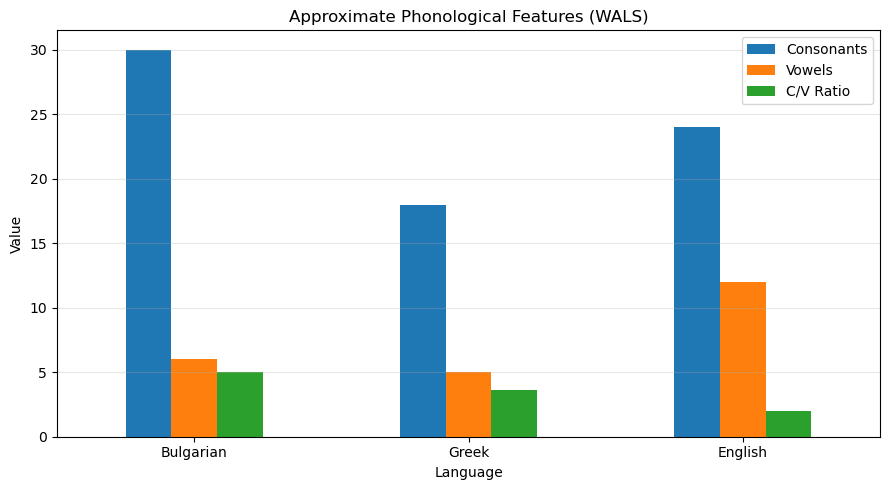

In [11]:
import matplotlib.pyplot as plt
import pandas as pd


data = {
    'Language': ['Bulgarian', 'Greek', 'English'],
    'Consonants': [30, 18, 24],
    'Vowels': [6, 5, 12],
    'C/V Ratio': [5.0, 3.6, 2.0]
}

df_wals = pd.DataFrame(data)


df_wals.set_index('Language')[['Consonants', 'Vowels', 'C/V Ratio']].plot(kind='bar', figsize=(9, 5))
plt.title('Approximate Phonological Features (WALS)')
plt.ylabel('Value')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Trilingual Case Study: Data Collection

## 3.1 Participants

- Two children (born 2017 and 2019, aged almost 9 and almost 7 at the time of the study)
- Languages: Bulgarian (BG), Greek (GR), English (EN)
- Location: Greece
- Language exposure:
    - Greek and English are dominant (school Monday–Friday, bilingual Greek/English environment)
    - Bulgarian is primarily used at home with me (the mother), during Saturday Bulgarian school (4 hours per week), and during occasional intensive exposure trips (e.g. February 20–23, 2026 trip to Bulgaria)




## 3.2 Experimental Design

- **Phonemes**: 12 comparable initial sounds (M, A, P, S, N, T, K, O, R, U(OO), L, E)
  - Chosen for approximate cross-linguistic equivalence across Bulgarian, Greek, and English
- **Task**: 10-minute timed word production per phoneme per language (children write as many words as possible starting with the given sound and sort them in three separate columns for each language)
- **Sessions**: Conducted across multiple dates (February–March 2026)
- **Exposure tracking**: The study records the normal weekly exposure pattern and notes periods of increased Bulgarian immersion, namely the February 20-23 trip to Bulgaria)

## 3.3 Data Structure
For each child-language pair, word counts are collected as a vector:
$$   (c_1, c_2, \dots, c_{12})   $$
where $  c_i  $ represents the number of words produced starting with phoneme $  i  $ during the 10-minute session.

These vectors form the basic numerical representation of phoneme-triggered lexical recall.

Additional dataset characteristics:

- **Total words collected**: 629
- **Raw counts** per phoneme, child, and language are recorded, along with spelling accuracy (correct/false) and type of the word (verb, noun, number, etc.)
- **Exposure differences** are not manually adjusted in the counts. Instead, exposure events (such as the February 20-23 immersion period) are recorded and later analyzed when comparing recall vectors accross sessions. 
- **Presentation**:
    - Summary tables (per phoneme, language and child)
    - Heatmaps of the 12×3 recall matrices per child
    - Pre/post-trip comparisons (especially Bulgarian vectors)
    - Summary statistics: mean counts, total words per language, vowel vs. consonant aggregates

### 3.3.1 Loading the Data

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


file_path = 'Phoneme Recall Results 060326.xlsx' 

df = pd.read_excel(file_path, sheet_name='Sheet1')

df.columns = df.columns.str.strip()  
df['Language'] = df['Language'].str.strip()
df['Phoneme'] = df['Phoneme'].str.strip()


print("Total words collected:", len(df))

Total words collected: 629


### 3.3.2 Summary Statistics
Total words, breakdown by language, child and phoneme

In [13]:
print("\nWords per language:")
print(df['Language'].value_counts())

print("\nWords per child and language:")
print(df.groupby(['Child', 'Language']).size().unstack(fill_value=0))

print("\nWords per phoneme (sorted by count):")
print(df['Phoneme'].value_counts().sort_values(ascending=False))


Words per language:
Language
GR    270
BG    188
EN    171
Name: count, dtype: int64

Words per child and language:
Language   BG   EN   GR
Child                  
M          66   62  106
T         122  109  164

Words per phoneme (sorted by count):
Phoneme
T        71
P        66
S        65
M        65
N        59
A        57
K        52
L        47
R        43
O        41
E        37
U(OO)    26
Name: count, dtype: int64


### 3.3.3 Building two separate 12 x 3 matrices per child
Each child-language combination produces a vector of phoneme recall counts.
Arranging these vectors as columns yields a 12 × 3 recall matrix, where rows correspond to phonemes and columns correspond to languages.

In [14]:
df_T = df[df['Child'] == 'T']
df_M = df[df['Child'] == 'M']

pivot_T = df_T.pivot_table(
    index='Phoneme',
    columns='Language',
    aggfunc='size',
    fill_value=0
)[['EN', 'GR', 'BG']] 

pivot_M = df_M.pivot_table(
    index='Phoneme',
    columns='Language',
    aggfunc='size',
    fill_value=0
)[['EN', 'GR', 'BG']]

M_T = pivot_T.values
M_M = pivot_M.values

print("Matrix for older child (T, 9 years):")
print("Shape of T matrix:", M_T.shape)
display(pivot_T)

print("\nMatrix for younger child (M, 7 years):")
print("Shape of M matrix:", M_M.shape)
display(pivot_M)

Matrix for older child (T, 9 years):
Shape of T matrix: (12, 3)


Language,EN,GR,BG
Phoneme,,,
A,10,18,9
E,3,15,2
K,9,13,10
L,8,11,10
M,11,18,13
N,9,10,17
O,7,11,6
P,8,29,10
R,10,8,9



Matrix for younger child (M, 7 years):
Shape of M matrix: (12, 3)


Language,EN,GR,BG
Phoneme,,,
A,4,11,5
E,5,6,6
K,6,7,7
L,5,6,7
M,7,8,8
N,8,8,7
O,5,11,1
P,5,7,7
R,6,5,5


### 3.3.4 Visualization: Heatmaps of Word Counts

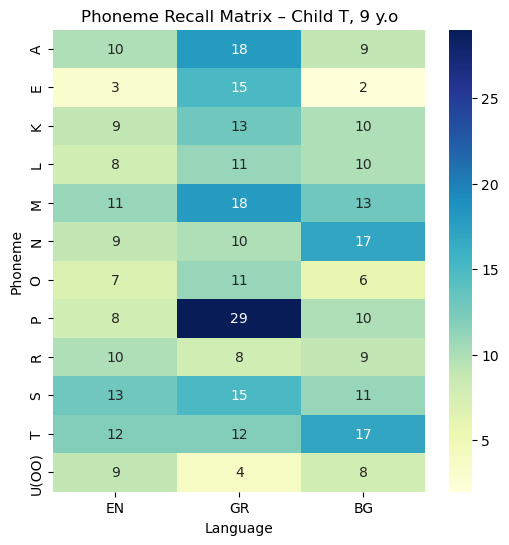

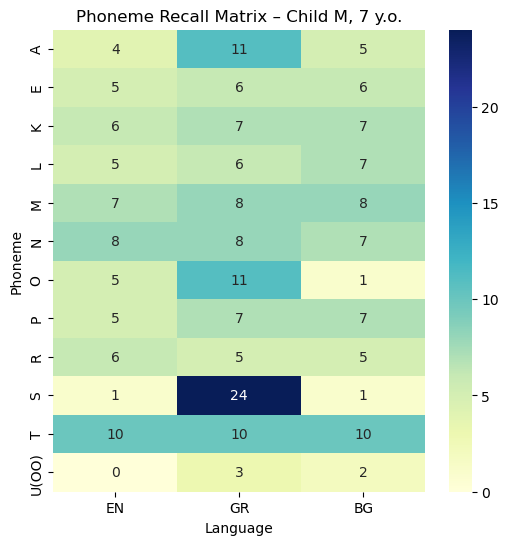

In [15]:
plt.figure(figsize=(6,6))
sns.heatmap(pivot_T, annot=True, cmap='YlGnBu')
plt.title("Phoneme Recall Matrix – Child T, 9 y.o")
plt.show()

plt.figure(figsize=(6,6))
sns.heatmap(pivot_M, annot=True, cmap='YlGnBu')
plt.title("Phoneme Recall Matrix – Child M, 7 y.o.")
plt.show()

### 3.3.5 Pre vs Post Trip Bulgarian Word Production

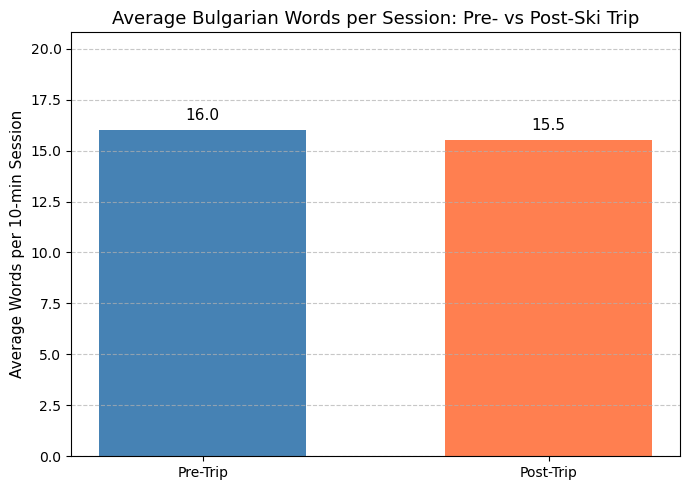

Pre-trip: 64 words across 4 sessions → 16.0 words/session
Post-trip: 124 words across 8 sessions → 15.5 words/session
Difference in average: -0.5 words/session


In [16]:
trip_cutoff = pd.to_datetime('2026-02-24')

bg_data = df[df['Language'] == 'BG'].copy()

bg_data['Period'] = np.where(bg_data['Date'] < trip_cutoff, 'Pre-Trip', 'Post-Trip')

sessions_pre = bg_data[bg_data['Period'] == 'Pre-Trip']['Date'].nunique()
sessions_post = bg_data[bg_data['Period'] == 'Post-Trip']['Date'].nunique()

words_pre = bg_data[bg_data['Period'] == 'Pre-Trip'].shape[0]
words_post = bg_data[bg_data['Period'] == 'Post-Trip'].shape[0]

avg_pre = words_pre / sessions_pre if sessions_pre > 0 else 0
avg_post = words_post / sessions_post if sessions_post > 0 else 0

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(
    ['Pre-Trip', 'Post-Trip'],
    [avg_pre, avg_post],
    color=['steelblue', 'coral'],
    width=0.6
)
ax.set_title('Average Bulgarian Words per Session: Pre- vs Post-Ski Trip', fontsize=13)
ax.set_ylabel('Average Words per 10-min Session', fontsize=11)
ax.set_ylim(0, max(avg_pre, avg_post) * 1.3)


for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.5,
            f'{height:.1f}', ha='center', fontsize=11)

ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(f"Pre-trip: {words_pre} words across {sessions_pre} sessions → {avg_pre:.1f} words/session")
print(f"Post-trip: {words_post} words across {sessions_post} sessions → {avg_post:.1f} words/session")
print(f"Difference in average: {avg_post - avg_pre:.1f} words/session")

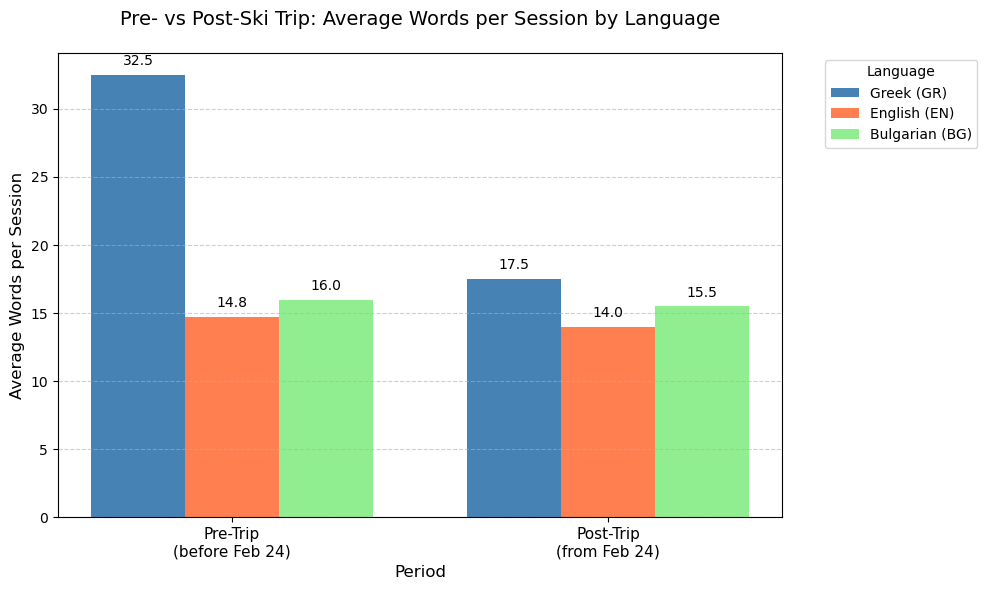

Average Words per Session (rounded):
Language     GR    EN    BG
Period                     
Post-Trip  17.5  14.0  15.5
Pre-Trip   32.5  14.8  16.0


In [10]:
trip_cutoff = pd.to_datetime('2026-02-24')

df['Period'] = np.where(df['Date'] < trip_cutoff, 'Pre-Trip', 'Post-Trip')

grouped = df.groupby(['Language', 'Period']).agg(
    words=('Word', 'count'),
    sessions=('Date', 'nunique')
).reset_index()

grouped['avg_per_session'] = grouped['words'] / grouped['sessions']

pivot_avg = grouped.pivot(index='Period', columns='Language', values='avg_per_session').fillna(0)
pivot_avg = pivot_avg[['GR', 'EN', 'BG']]  

fig, ax = plt.subplots(figsize=(10, 6))  

x = np.arange(2)
width = 0.25 

ax.bar(x[0] - width, pivot_avg.loc['Pre-Trip', 'GR'], width, label='Greek (GR)', color='steelblue')
ax.bar(x[0], pivot_avg.loc['Pre-Trip', 'EN'], width, label='English (EN)', color='coral')
ax.bar(x[0] + width, pivot_avg.loc['Pre-Trip', 'BG'], width, label='Bulgarian (BG)', color='lightgreen')

ax.bar(x[1] - width, pivot_avg.loc['Post-Trip', 'GR'], width, color='steelblue')
ax.bar(x[1], pivot_avg.loc['Post-Trip', 'EN'], width, color='coral')
ax.bar(x[1] + width, pivot_avg.loc['Post-Trip', 'BG'], width, color='lightgreen')

ax.set_xlabel('Period', fontsize=12)
ax.set_ylabel('Average Words per Session', fontsize=12)
ax.set_title('Pre- vs Post-Ski Trip: Average Words per Session by Language', fontsize=14, pad=20)
ax.set_xticks(x)
ax.set_xticklabels(['Pre-Trip\n(before Feb 24)', 'Post-Trip\n(from Feb 24)'], fontsize=11)
ax.legend(title='Language', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.6)

for i, period in enumerate(['Pre-Trip', 'Post-Trip']):
    for j, lang in enumerate(['GR', 'EN', 'BG']):
        val = pivot_avg.loc[period, lang]
        if val > 0:
            ax.text(x[i] + (j - 1) * width, val + 0.5, f'{val:.1f}',
                    ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print("Average Words per Session (rounded):")
print(pivot_avg.round(1))

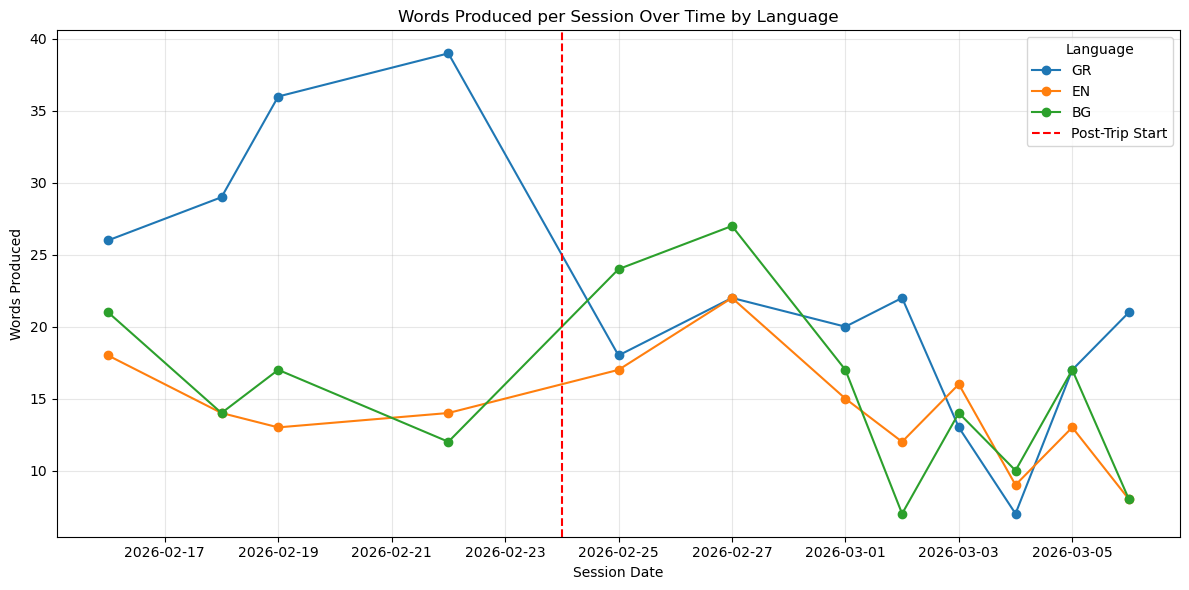

In [17]:
df['Date'] = pd.to_datetime(df['Date'])
session_counts = df.groupby(['Date', 'Language']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 6))
for lang in ['GR', 'EN', 'BG']:
    plt.plot(session_counts.index, session_counts[lang], marker='o', label=lang)

plt.axvline(pd.to_datetime('2026-02-24'), color='red', linestyle='--', label='Post-Trip Start')
plt.title('Words Produced per Session Over Time by Language')
plt.xlabel('Session Date')
plt.ylabel('Words Produced')
plt.legend(title='Language')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Key Observation**  
So, contrary to my initial informal impression, although there was a brief spike immediately after the trip, when normalized for the number of sessions, **average Bulgarian word production per 10-minute session actually decreased after the February 20–23, 2026 trip**. Greek and English word production decreased as well.  

Possible explanations include:
- Different phonemes tested pre- vs post-trip (some easier/harder).
- Less excitement and reduced motivation for the experiment.
- The trip's immersion effect was short-lived or not strong enough to impact recall in these sessions.

I will explore this finding further in Section 4 (vector norms) and Section 5 (experiments), where I will model exposure effects mathematically.

# 4. Vector and Matrix Modeling

In this section I will formalize the collected data into mathematical objects using concepts from the course (vectors, matrices, dot product, cosine similarity).  


## 4.1 Representing the Data as Matrices

After collecting the phoneme recall data, the responses were organized into matrices that summarize how often each phoneme appeared in each language. Rather than combining both children into one structure, two separate matrices were constructed — one for each child.

Each matrix has:
- **Rows**: the twelve phonemes tested in the experiment
- **Columns**: the three languages (English, Greek, Bulgarian)
- **Entries**: the number of recalled words beginning with that phoneme in that language

This produces the 12 × 3 matrix for each child, which I already introduced in Section 3.3.3.
Separating the matrices by child allows each child’s phonological recall patterns to be analyzed independently before comparisons are made.


## 4.2 From Matrices to Vectors

Once the data is organized in matrix form, each language column can be interpreted as a vector in a 12-dimensional space.

For example:
- English vector: $\vec{v}_{EN}$
- Greek vector: $\vec{v}_{GR}$
- Bulgarian vector: $\vec{v}_{BG}$

Each component of the vector corresponds to the frequency of a particular phoneme. So the English vector for one child might look conceptually like:  
$$ \vec{v}_{EN} = (x_1, x_2, x_3, \dots, x_{12})  $$

where each $ x_i $ is the number of recalled English words beginning with phoneme $ i $.

Representing the languages as vectors allows for the application of linear algebra tools to compare their phoneme distributions.
The vectors used in the analysis are extracted directly from the matrix columns using NumPy arrays:

In [18]:
v_T_EN = pivot_T['EN'].values
v_T_GR = pivot_T['GR'].values
v_T_BG = pivot_T['BG'].values

v_M_EN = pivot_M['EN'].values
v_M_GR = pivot_M['GR'].values
v_M_BG = pivot_M['BG'].values

print("Vector shape:", v_T_EN.shape)
print("Sample (T-EN first 5 components):", v_T_EN[:5])

Vector shape: (12,)
Sample (T-EN first 5 components): [10  3  9  8 11]


In [19]:
norms = {
    'T-EN': np.linalg.norm(v_T_EN),
    'T-GR': np.linalg.norm(v_T_GR),
    'T-BG': np.linalg.norm(v_T_BG),
    'M-EN': np.linalg.norm(v_M_EN),
    'M-GR': np.linalg.norm(v_M_GR),
    'M-BG': np.linalg.norm(v_M_BG)
}

norms_df = pd.DataFrame.from_dict(norms, orient='index', columns=['Norm']).round(2)
norms_df = norms_df.sort_values('Norm', ascending=False)
print("Vector Norms (using np.linalg.norm):")
display(norms_df)

Vector Norms (using np.linalg.norm):


,Norm
T-GR,51.71
T-BG,37.87
M-GR,35.36
T-EN,32.60
M-BG,21.26
M-EN,20.05


## 4.3 Measuring Language Similarity

To compare how similar two languages are in terms of phoneme recall patterns, I use **cosine similarity**. This metric measures the angle between two vectors rather than their absolute magnitude.

The cosine similarity between two vectors $\vec{A}$ and $\vec{B}$ is defined as:  
$$
\cos(\theta) = \frac{\vec{A} \cdot \vec{B}}{\|\vec{A}\| \|\vec{B}\|}
$$
Where:
- $\vec{A} \cdot \vec{B}$ is the dot product
- $\|\vec{A}\|$ and $\|\vec{B}\|$ are the vector magnitudes (Euclidean norms)
- $\theta$ is the angle between the vectors

The result ranges from:
- **1**: identical phoneme distributions (perfect alignment)
- **0**: no similarity (orthogonal patterns)
- **-1**: completely opposite patterns

In this experiment, cosine similarity allows for the comparison of:
- English vs Greek
- English vs Bulgarian
- Greek vs Bulgarian

for each child separately.

Because cosine similarity focuses on direction rather than magnitude, it compares the pattern of phoneme usage rather than the total number of words recalled.

In [20]:
def cosine_sim(a: np.ndarray, b: np.ndarray) -> float:
    norm_a = np.linalg.norm(a)
    norm_b = np.linalg.norm(b)
    if norm_a == 0 or norm_b == 0:
        return 0.0
    return np.dot(a, b) / (norm_a * norm_b)

sim_T = {
    'GR-EN': cosine_sim(v_T_GR, v_T_EN),
    'GR-BG': cosine_sim(v_T_GR, v_T_BG),
    'EN-BG': cosine_sim(v_T_EN, v_T_BG)
}

sim_M = {
    'GR-EN': cosine_sim(v_M_GR, v_M_EN),
    'GR-BG': cosine_sim(v_M_GR, v_M_BG),
    'EN-BG': cosine_sim(v_M_EN, v_M_BG)
}

print("Cosine Similarity – Older Child (T):")
display(pd.Series(sim_T).round(3).to_frame('Similarity'))

print("\nCosine Similarity – Younger Child (M):")
display(pd.Series(sim_M).round(3).to_frame('Similarity'))

Cosine Similarity – Older Child (T):


,Similarity
GR-EN,0.879
GR-BG,0.850
EN-BG,0.966



Cosine Similarity – Younger Child (M):


,Similarity
GR-EN,0.719
GR-BG,0.688
EN-BG,0.962


## 4.4 Usefulness of the Cosine Similarity

The children did not necessarily produce the same number of words in each language (e.g., the older child produced more overall, and Greek dominated both). A simple comparison of raw counts could therefore be misleading. Cosine similarity avoids this problem by normalizing the vectors.

This means the analysis focuses on how the phonemes are distributed across languages, rather than how many total words were produced.

In practical terms, cosine similarity helps answer questions such as:
- Does English phoneme recall resemble Greek or Bulgarian more closely?
- Are the phoneme patterns similar between the two children?
- Do certain languages cluster together in phonological structure?

These comparisons form the basis of the quantitative analysis presented in the next section.

# 5. Experiments and Analysis
This section will apply statistical and probabilistic tools from the course to analyze the recall data and address the research questions from Section 1.3. All experiments operate on the 12-dimensionl language vectors from Section 4 and the raw session data from Section 3. 

## 5.1 Experiment 1: Descriptive Statistics per Language Vector for Each Child
For each child-language vector $\vec{v}_{k,L}$ I calculate the mean, median, standard deviation and skewness of the 12 phoneme counts. These reveal whether recall is spread evenly accross phonemes or concentraded around few "easy" ones.

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew

def vector_stats(v, label):
    return {
        'Label':    label,
        'Mean':     np.mean(v),
        'Median':   np.median(v),
        'Std Dev':  np.std(v, ddof=1),  # unbiased estimator
        'Skewness': skew(v),
        'Min':      np.min(v),
        'Max':      np.max(v)
    }

records = [
    vector_stats(v_T_EN, 'T-EN'), vector_stats(v_T_GR, 'T-GR'),
    vector_stats(v_T_BG, 'T-BG'), vector_stats(v_M_EN, 'M-EN'),
    vector_stats(v_M_GR, 'M-GR'), vector_stats(v_M_BG, 'M-BG'),
]

stats_df = pd.DataFrame(records).set_index('Label').round(2)
print("Descriptive Statistics per Language Vector:")
display(stats_df)

Descriptive Statistics per Language Vector:


,Mean,Median,Std Dev,Skewness,Min,Max
Label,,,,,,
T-EN,9.08,9.0,2.57,-0.80,3,13
T-GR,13.67,12.5,6.27,1.00,4,29
T-BG,10.17,10.0,4.20,0.04,2,17
M-EN,5.17,5.0,2.72,-0.32,0,10
M-GR,8.83,7.5,5.34,1.99,3,24
M-BG,5.50,6.5,2.84,-0.43,1,10


As we can see, the older child (T) produces consistently higher recall across all three languages (Greek mean: 13.67, Bulgarian: 10.17, English: 9.1) compared to the younger child (M) (Greek mean: 8.83, Bulgarian: 5.50, English: 5.17) which reflects a natural age-related greater vocabulary productivity.

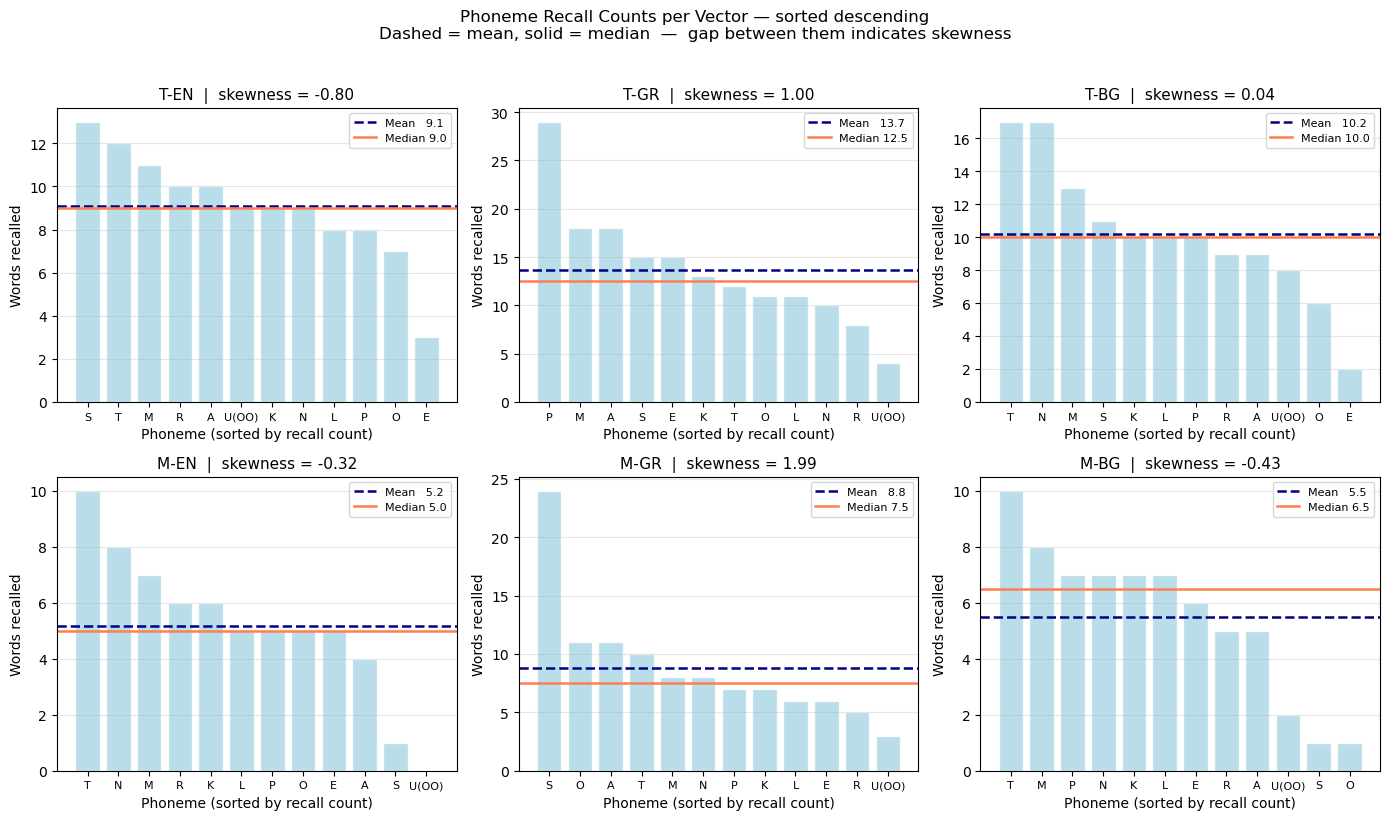

In [22]:
vectors = {
    'T-EN': v_T_EN, 'T-GR': v_T_GR, 'T-BG': v_T_BG,
    'M-EN': v_M_EN, 'M-GR': v_M_GR, 'M-BG': v_M_BG,
}

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, (label, v) in zip(axes, vectors.items()):
    mean   = np.mean(v)
    median = np.median(v)
    sk     = skew(v)

    sorted_v = np.sort(v)[::-1]
    phoneme_labels = pivot_T.index[np.argsort(v)[::-1]] if 'T' in label \
                     else pivot_M.index[np.argsort(v)[::-1]]

    ax.bar(range(12), sorted_v, color='lightblue', edgecolor='white', alpha=0.85)
    ax.set_xticks(range(12))
    ax.set_xticklabels(phoneme_labels, fontsize=8)

    ax.axhline(mean,   color='navy',  linestyle='--', linewidth=1.8,
               label=f'Mean   {mean:.1f}')
    ax.axhline(median, color='coral', linestyle='-',  linewidth=1.8,
               label=f'Median {median:.1f}')

    ax.set_title(f'{label}  |  skewness = {sk:.2f}', fontsize=11)
    ax.set_xlabel('Phoneme (sorted by recall count)')
    ax.set_ylabel('Words recalled')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle(
    'Phoneme Recall Counts per Vector — sorted descending\n'
    'Dashed = mean, solid = median  —  gap between them indicates skewness',
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.show()

The skewness values reveal meaningfully different distribution shapes across languages.
The Greek vectors stand out for both children: T-GR (skewness = 1.00) and especially M-GR (skewness= 1.99) which is driven by one or two phonemes with exceptionally high recall (like P in child T with 29 words and S in child M with 24 words). In both cases the mean sits way above the median which is the visual mark of positive skew.
English shows a different pattern. Both T-EN(skewness -0.80) and M-EN (skewness -0.32) are slightly negatively skewed, which is caused by a few low performing phonemes (E and U(OO) in T-EN, S and U(OO) in M-EN). 
As far as the Bulgarian vectors are concerned, T-BG appears the most symmetric (skewness 0.04). This, however, does not mean that the distribution is narrow or uniform. As we can see, the extreme values (phonemes T, N at the top and phonemes O, E at the bottom) are balanced on both sides. For child M, M-BG is slightly negatively skewed due to extremely low recall on phonemes O, S and U(OO), possibly reflecting age-related issues with limited and unevenly distributed Bulgarian vocabulary. 

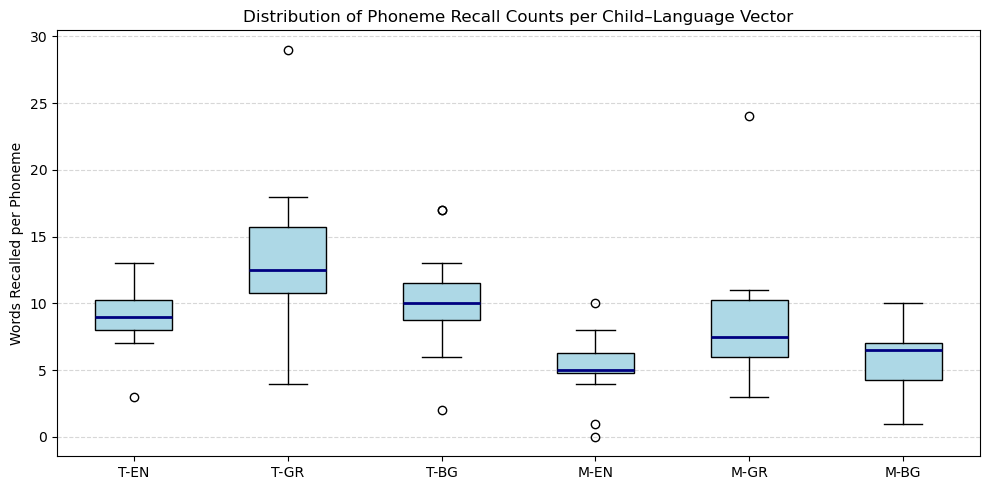

In [23]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(
    [v_T_EN, v_T_GR, v_T_BG, v_M_EN, v_M_GR, v_M_BG],
    tick_labels=['T-EN', 'T-GR', 'T-BG', 'M-EN', 'M-GR', 'M-BG'],
    patch_artist=True,
    boxprops=dict(facecolor='lightblue'),
    medianprops=dict(color='navy', linewidth=2)
)
ax.set_title('Distribution of Phoneme Recall Counts per Child–Language Vector',
             fontsize=12)
ax.set_ylabel('Words Recalled per Phoneme')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

The above boxplot places all six vectors on a common scale for direct comparison.
T-GR has both the highest median and the widest interquartile range (9-16), which reflects not only strong overall recall but also high variability across phonemes. The outlier point at 29 is phoneme P, the strongest recall result in the entire dataset. M-GR shows a similar pattern at a lower level with its own outlier, phoneme S, at 24. The English vectors are represented by the shortest boxes, suggesting the most consistent phoneme-level recall in English, without extreme highs or lows.


## 5.2 Experiment 2: Statistical Test for the Trip Effect
Section 3.3.5 showed that average Bulgarian word production per session decreased after the February 20–23 trip, contrary to the initial informal impression. 
Here I quantify that observation using a z-score: how far does the post-trip mean sit from the pre-trip baseline, measured in standard deviations?
Note: The z-score is used as a descriptive tool — a standardised measure of effect size, not a claim of statistical significance.

In [24]:
from scipy.stats import norm

trip_cutoff = pd.to_datetime('2026-02-24')

bg_sessions = (
    df[df['Language'] == 'BG']
    .groupby('Date').size()
    .reset_index(name='words')
)
bg_sessions['Period'] = np.where(
    bg_sessions['Date'] < trip_cutoff, 'Pre-Trip', 'Post-Trip'
)

pre  = bg_sessions[bg_sessions['Period'] == 'Pre-Trip']['words']
post = bg_sessions[bg_sessions['Period'] == 'Post-Trip']['words']

pre_mean = pre.mean()
post_mean = post.mean()
pre_std  = pre.std(ddof=1)
se       = pre_std / np.sqrt(len(post))
z        = (post_mean - pre_mean) / se

print(f"Pre-trip  sessions : {len(pre)}  |  mean = {pre_mean:.2f}  |  std = {pre_std:.2f}")
print(f"Post-trip sessions : {len(post)} |  mean = {post_mean:.2f}")
print(f"Difference (post − pre) : {post_mean - pre_mean:.2f} words/session")
print(f"Z-score                 : {z:.2f}")

p_descriptive = norm.cdf(z)
print(f"\nP(session mean ≤ post-trip mean) under pre-trip normal model ≈ {p_descriptive:.3f}")
print("(Descriptive only — not a formal hypothesis test.)")

Pre-trip  sessions : 4  |  mean = 16.00  |  std = 3.92
Post-trip sessions : 8 |  mean = 15.50
Difference (post − pre) : -0.50 words/session
Z-score                 : -0.36

P(session mean ≤ post-trip mean) under pre-trip normal model ≈ 0.359
(Descriptive only — not a formal hypothesis test.)


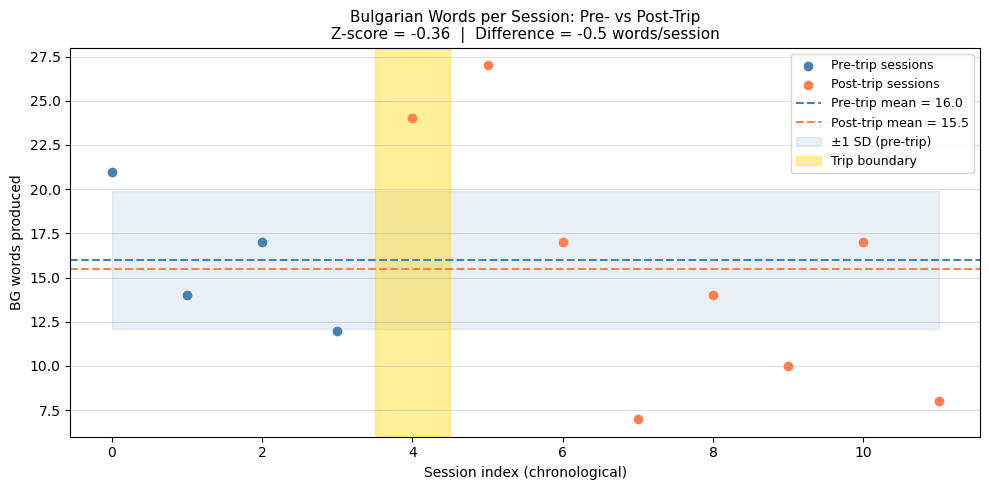

In [25]:
fig, ax = plt.subplots(figsize=(10, 5))

pre_x  = np.arange(len(pre))
post_x = np.arange(len(pre), len(pre) + len(post))

ax.scatter(pre_x,  pre.values,  color='steelblue', label='Pre-trip sessions',  zorder=3)
ax.scatter(post_x, post.values, color='coral',     label='Post-trip sessions', zorder=3)
ax.axhline(pre_mean,  color='steelblue', linestyle='--', linewidth=1.5,
           label=f'Pre-trip mean = {pre_mean:.1f}')
ax.axhline(post_mean, color='coral',     linestyle='--', linewidth=1.5,
           label=f'Post-trip mean = {post_mean:.1f}')
ax.fill_between(range(len(bg_sessions)),
                pre_mean - pre_std, pre_mean + pre_std,
                alpha=0.12, color='steelblue', label='±1 SD (pre-trip)')
ax.axvspan(len(pre) - 0.5, len(pre) + 0.5, color='gold', alpha=0.4,
           label='Trip boundary')
ax.set_title(
    f'Bulgarian Words per Session: Pre- vs Post-Trip\n'
    f'Z-score = {z:.2f}  |  Difference = {post_mean - pre_mean:.1f} words/session',
    fontsize=11
)
ax.set_xlabel('Session index (chronological)')
ax.set_ylabel('BG words produced')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

The post-trip mean of 15.5 Bulgarian words per session is slightly lower than the pre-trip mean (16.0). The z-score of -0.36 places the post-trip mean well within the ± SD band - a result this low would occur in 36% of sessions by chance alone, confirming that the difference is unremarkable. 
The chart makes this visually clear - the two mean lines almost coincide and the post-trip sessions show the same wide variability as the pre-trip ones. The two highest producing Bulgarian sessions actually occur immediately after the trip, which is what created the initial informal impression of a Bulgarian boost. When normalized across all post-trip sessions, however, that spike does not shift the average meaningfully.

The conclusion is that there is no detectable effect of the ski trip on Bulgarian production in the dataset. 

## 5.3 Experiment 3: Pearson Correlation Between Language Vectors

Cosine similarity (Section 4.3) measures the angle between vectors. Pearson correlation is complementary: it measures the linear co-variation after centring each vector on its mean, and is equivalent to the cosine similarity of the mean-centered vectors. A high GR-EN correlation here would mean that phonemes that were "easy" in Greek were also easy in English. 

$$ r = \frac{\sum_{i=1}^{12}(a_i - \bar{a})(b_i - \bar{b})}{\sqrt{\sum_{i=1}^{12}(a_i - \bar{a})^2} \cdot \sqrt{\sum_{i=1}^{12}(b_i - \bar{b})^2}} $$

where $a_i, b_i$ represent the phoneme $i$ in each of the two languages being compared; $\bar{a}, \bar{b}$ represent the mean word count across all 12 phonemes for each language, while $(a_i - \bar{a})$ shows how far phoneme $i$ sits from its language's average (the deviation).

In [26]:
def cosine_sim(a, b):
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    return np.dot(a, b) / (na * nb) if na > 0 and nb > 0 else 0.0

pairs = [('EN', 'GR'), ('GR', 'BG'), ('EN', 'BG')]
rows  = []
for child, pivot in [('T', pivot_T), ('M', pivot_M)]:
    for l1, l2 in pairs:
        x, y = pivot[l1].values, pivot[l2].values
        rows.append({
            'Child':      child,
            'Pair':       f'{l1}–{l2}',
            'Pearson r':  round(np.corrcoef(x, y)[0, 1], 3),
            'Cosine sim': round(cosine_sim(x, y), 3)
        })

comparison_df = pd.DataFrame(rows)
print("Pearson Correlation vs Cosine Similarity:")
display(comparison_df)

Pearson Correlation vs Cosine Similarity:


,Child,Pair,Pearson r,Cosine sim
0,T,EN–GR,-0.043,0.879
1,T,GR–BG,-0.008,0.850
2,T,EN–BG,0.714,0.966
3,M,EN–GR,-0.235,0.719
4,M,GR–BG,-0.395,0.688
5,M,EN–BG,0.809,0.962


The most interesting result is the divergence between Pearson r and cosine similarity. Cosine similarity is high for every pear but Pearson r is mostly negative which reveals that phonemes productive in Greek are not the same ones productive in English or Bulgarian (e.g. P renders 29 words in Greek for the older child T, but only 8 in English). Another interesting finding is that EN-BG shows the strongest Pearson correlations (Child T: 0.714, Child M: 0.809), suggesting that in this case English and Bulgarian recall patterns align more closely in terms of phoneme recall than Greek and English do, despite Greek and English sharing the school environment. This may be an interesting thing to investigate further with a larger sample.

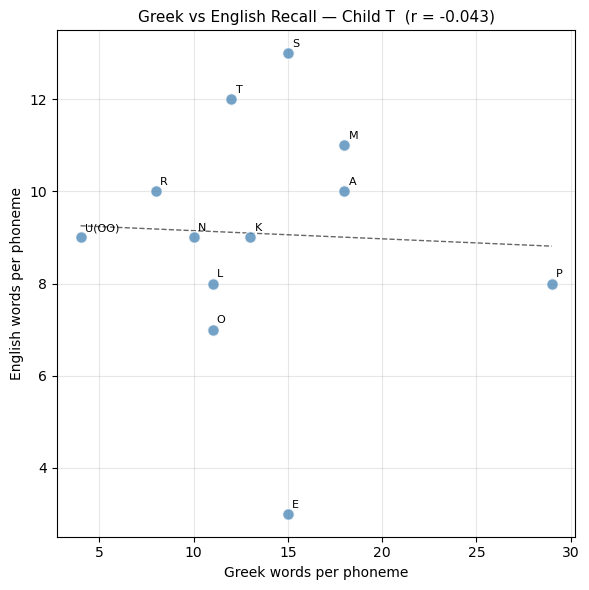

In [27]:
x = pivot_T['GR'].values
y = pivot_T['EN'].values
r = np.corrcoef(x, y)[0, 1]

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(x, y, color='steelblue', alpha=0.75, edgecolors='white', s=70, zorder=3)

for i, ph in enumerate(pivot_T.index):
    ax.annotate(ph, (x[i], y[i]), fontsize=8, ha='left', va='bottom',
                xytext=(3, 3), textcoords='offset points')

m, b = np.polyfit(x, y, 1)
x_line = np.linspace(min(x), max(x), 100)
ax.plot(x_line, m * x_line + b, 'k--', linewidth=1, alpha=0.6)

ax.set_title(f'Greek vs English Recall — Child T  (r = {r:.3f})', fontsize=11)
ax.set_xlabel('Greek words per phoneme')
ax.set_ylabel('English words per phoneme')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The scatter plot for child T's Greek vs English recall clearly shows the near-zero correlation - the poiints are scattered with no visible pattern whatsoever and the trendline is almost flat. Phoneme P is the nost extreme example with 29 Greek words, but only 8  in English.
I will next examine whether this language-specificity of phoneme productivity is also valid to the vowel/consonant distinction.

## 5.4 Experiment 4: Vowel vs. Consonant Analysis
The 12 phonemes used in the experiment consist of 4 vowels (A, E, O, U(OO) and 8 consonants (M, P, S, N, T, K, R, L). I will use this sub-division of vowels and consnonants to break each recall vector into two sub-vectors. Because the two groups are unequal in size (4 vs 8), comparing the raw norms would be unfair. The per phoneme mean would be the more honest comparison, as it will control for the fact that connsnonants simply have more members in the study.

In [28]:
phoneme_order = list(pivot_T.index)
vowels     = ['A', 'E', 'O', 'U(OO)']
consonants = [p for p in phoneme_order if p not in vowels]

rows = []
for child, pivot in [('T', pivot_T), ('M', pivot_M)]:
    for lang in ['EN', 'GR', 'BG']:
        v_sub = pivot.loc[vowels, lang].values
        c_sub = pivot.loc[consonants, lang].values
        c_norm = np.linalg.norm(c_sub)
        rows.append({
            'Child':             child,
            'Language':          lang,
            'Vowel mean/ph':     round(np.mean(v_sub), 2),
            'Consonant mean/ph': round(np.mean(c_sub), 2),
            'Vowel norm':        round(np.linalg.norm(v_sub), 2),
            'Consonant norm':    round(c_norm, 2),
            'Norm ratio V/C':    round(
                np.linalg.norm(v_sub) / c_norm if c_norm > 0 else float('nan'), 3
            )
        })

vc_df = pd.DataFrame(rows)
print("Vowel vs. Consonant Sub-vector Analysis:")
display(vc_df)

Vowel vs. Consonant Sub-vector Analysis:


,Child,Language,Vowel mean/ph,Consonant mean/ph,Vowel norm,Consonant norm,Norm ratio V/C
0,T,EN,7.25,10.00,15.46,28.71,0.539
1,T,GR,12.00,14.50,26.19,44.59,0.587
2,T,BG,6.25,12.12,13.60,35.34,0.385
3,M,EN,3.50,6.00,8.12,18.33,0.443
4,M,GR,7.75,9.38,16.94,31.03,0.546
5,M,BG,3.50,6.50,8.12,19.65,0.414


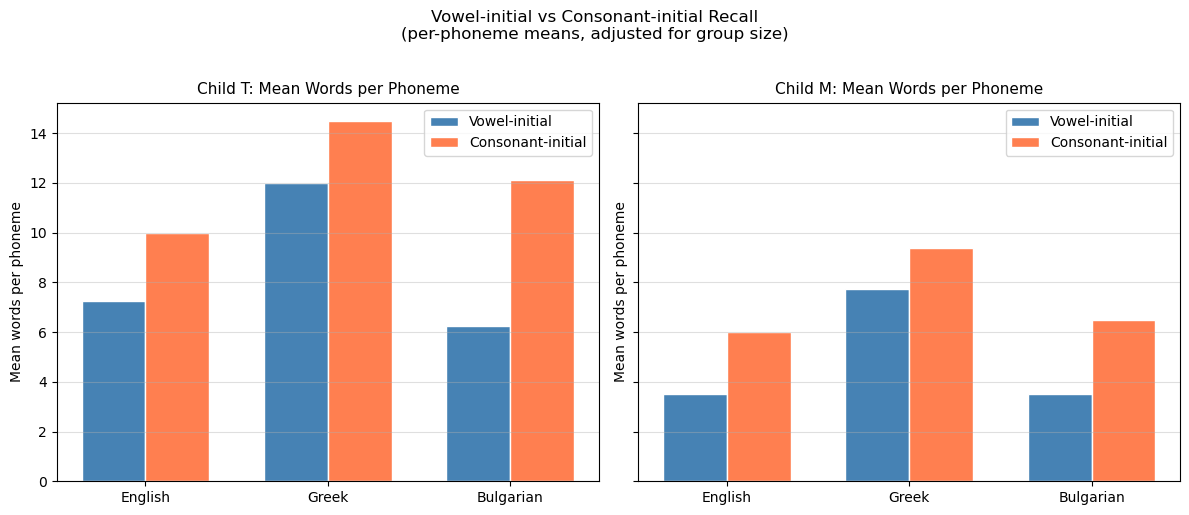

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, child in zip(axes, ['T', 'M']):
    data = vc_df[vc_df['Child'] == child]
    x    = np.arange(3)
    w    = 0.35
    ax.bar(x - w/2, data['Vowel mean/ph'],
           w, label='Vowel-initial',     color='steelblue', edgecolor='white')
    ax.bar(x + w/2, data['Consonant mean/ph'],
           w, label='Consonant-initial', color='coral', edgecolor='white')
    ax.set_title(f'Child {child}: Mean Words per Phoneme', fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(['English', 'Greek', 'Bulgarian'])
    ax.set_ylabel('Mean words per phoneme')
    ax.legend()
    ax.grid(axis='y', alpha=0.4)

plt.suptitle('Vowel-initial vs Consonant-initial Recall\n'
             '(per-phoneme means, adjusted for group size)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

It is evident that consonants outperform vowels across every language and in both children. The norm ratio vowels/ consonants is below 0.6 in all six cases, confirming the pattern is consistent rather than language-specific. The gap is smallest in Greek for child T (vowel mean 12.0 vs consonant mean 14.5), with the two groups having strong overall recall. It is largest in Bulgarian for both children (T: 6.25 vs 12.12, M: 3.50 vs 6.50), suggesting that as overall vocabulary access weakens, voweli-initial recall suffers disproportionately. This answers Research Question 1: vowel-initial phonemes do not yield higher recall - consonants are consistently more productive across across all three languages in this study. It is also worth noting that English has a much larger vowel quality inventory than Greek or Bulgarian per WALS (12 vs 5 and 6) and yet the disadvantage persists in English too, indicating that typological inventory size does not straightforwardly predict individual recall productivity.

## 5.5 Experiment 5: Comparing WALS Typological Distances to Recall Similarity
Section 2 introduced WALS feature vectors $\vec{g}_L = (c_L, v_L, r_L)$ for each language. The cosine similarities between recall vectors in have been calculated in Section 4.3, and the present experiment will investigate whether the languages that are typologically similar according to WALS also produce more similar recall paterns in the children.

In [30]:
wals = {
    'EN': np.array([24.0, 12.0, 2.0]),
    'GR': np.array([18.0,  5.0, 3.6]),
    'BG': np.array([30.0,  6.0, 5.0]),
}

combined = pd.DataFrame({
    'WALS cosine sim': {
        'EN–GR': round(cosine_sim(wals['EN'], wals['GR']), 3),
        'GR–BG': round(cosine_sim(wals['GR'], wals['BG']), 3),
        'EN–BG': round(cosine_sim(wals['EN'], wals['BG']), 3),
    },
    'Recall sim (T)': {
        'EN–GR': sim_T['GR-EN'],
        'GR–BG': sim_T['GR-BG'],
        'EN–BG': sim_T['EN-BG']
    },
    'Recall sim (M)': {
        'EN–GR': sim_M['GR-EN'],
        'GR–BG': sim_M['GR-BG'],
        'EN–BG': sim_M['EN-BG']
    }
})

print("WALS Typological Similarity vs Personal Recall Similarity:")
display(combined)

WALS Typological Similarity vs Personal Recall Similarity:


,WALS cosine sim,Recall sim (T),Recall sim (M)
EN–GR,0.975,0.879024,0.719453
GR–BG,0.997,0.850274,0.687807
EN–BG,0.961,0.966272,0.961837


The first thing to note is that the three WALS similarity values are within a very tight range (between 0.961 and 0.997). This means that the three languages are almost indistinguishable at this level of typological representation. This is a limitation of the 3-dimensional WALS feature vector: it is too coarse to capture meaningful structural differences between these particular languages.
Despite this, the comparison is revealing. WALS ranks GR-BG as the most similar language pair (0.997) and EN-BG as the least (0.961). The childrens' recall similarities tell the oposite story: EN-BG is the strongest pair for both children (T: 0.966, M: 0.962) while GR-BG is the weakest (T: 0.850, M: 0.688). The ranking is completely reversed. 

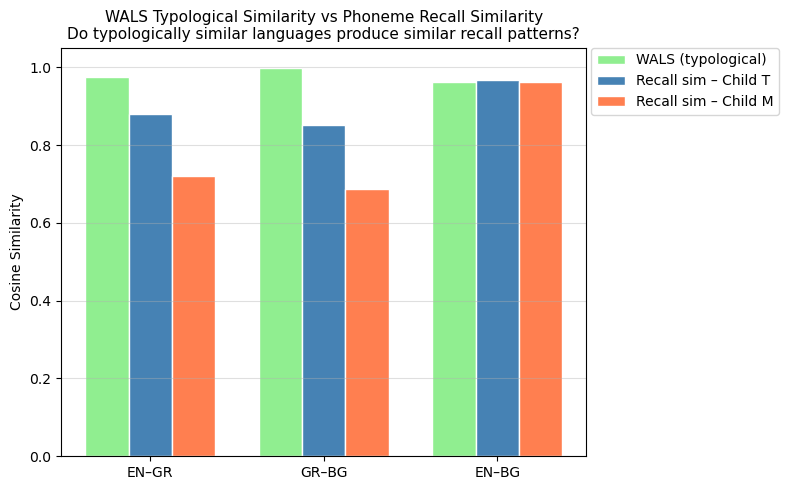

In [33]:
fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(3)
labels = ['EN–GR', 'GR–BG', 'EN–BG']
width = 0.25

ax.bar(x - width, combined['WALS cosine sim'], width,
       label='WALS (typological)', color='lightgreen', edgecolor='white')
ax.bar(x, combined['Recall sim (T)'], width,
       label='Recall sim – Child T', color='steelblue', edgecolor='white')
ax.bar(x + width, combined['Recall sim (M)'], width,
       label='Recall sim – Child M', color='coral', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Cosine Similarity')
ax.set_title('WALS Typological Similarity vs Phoneme Recall Similarity\n'
             'Do typologically similar languages produce similar recall patterns?',
             fontsize=11)
ax.set_ylim(0, 1.05)
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

The above findings suggest that in this case, daily exposure patterns, rather than typological structure, drive recall similarity - English and Bulgarian are the most aligned in recall because neither dominates the childrens' environment the way Greek does, not because they are phonologically close.

# 6. Discussion

## 6.1 Key Findings
Five experiments were conducted, using tools from linear algerbra and statistics. Together they produced the following findings:

### Descriptive patterns and differences between children
Child T consitently outperforms child M across all three languages - Greek (13.7 vs 8.8 words per phoneme), Bulgarian (10.2 vs 5.5) and English (9.1 vs 5.2). This is expected given the two-year age gap. Greek dominates for both, reflecting its role as the primary everyday language. More interestingly, the distribution shapes differ accross languages: Greek is strongly right-skewed for both children (T: 1.00, M: 1.99) driven by few dominant phonemes, while Bulgarian for child T is remarkably symmetric (0.04) - not because the counts are similar, but because its high and low estremes balance each other out.

### Vowel vs consonant recall
Consonants outperform vowels consistently, across all three languages and both children, with norm ratios vowel/consonant below 0.6 in every case. The gap is widest in Bulgarian (T: 6.25 vs 12.12 per phoneme, M: 3.50 vs 6.50), suggesting that as overall access to language weakens, vowel-initial recall is affected the most.

### Language exposure and the ski-trip effect
The February ski trip effect to Bulgaria left no detectable trace in the data. The post-trip mean (15.5 words/session) was almost identical to the pre-trip mean (16.0), with a z-score of -0.36, which is well within normal session-to-session variation. The initial impression of a Bulgarian boost did not hold up once the session counts were normalized.

### Language similarity
WALS typological similarities are so tightly clustered (0.961-0.997) that the three languages are almost indestinguishable at this level of representation. The children's recall similarities tell a more interesting story: EN-BG is the strongest pair for both children (T: 0.996, M: 0.962) while GR-BG is the weakest (T: 0.850, M: 0.688), reverisng the WALS ranking. Pearson correlation point the same way: GR-EN and GR-BG are near zero or negative, while EN-BG are the most aligned pair (T: 0.714, M: 0.809). So, in this case at least, exposure wins over structure.


## 6.2 Limitations
The most obvious limitation of this project is the sample size: two children from the same family, being raised in the same environment, cannot support any generalization beyond this specific case. Phoneme selection also introduces bias - the 12 phonemes were chosen for cross-linguistic comparability, which means that the results reflect that particular subset rather than the full phonological space of each language. Session variability is another concern - motivation, tiredness and the specific phonemes tested on a given day are all uncontrolled, contributing to the wide spread visible in the data. The ski-trp analysis is especially affected by this - other things changed atound this time besides Bulgarian exposure, which makes it impossible to isolate any immersion effect even if there was one. Finaly, the WALS feature vectors in Experiment 5 reduce each language to just three numbers, which proved too rough to meaningfully differentiate the three languages from each other.

This study makes no claim to statistical generalizability. With only two participants and a limited number of sessions, the results are descriptive and exploratory. The value of this case study lies in demonstrating how mathematical tools - vectors, matrices, norms, cosine similarity and distributional models can be systematically applied to a real, if small, linguistic dataset, and in generalizing hypotheses that a larger study could test.

# 7. Conclusion
This project began with a simple observation made on the living room floor: two children switching between three languages and a mother wondering whether there was a pattern worth measuring. The mathematics said there was.

The tools seemed to work - vectors, norms, cosine similarity and a z-score that quietly deflated an exciting hypothesis, and they gradually turned an informal family obesrvation into something structured and analyzable. That feels like a real result, more than any individual finding.

What this project cannot do is generalize. Two children, one family, just a few sessions - the findings are a starting point, not a conclusion. But that was my point all along: to show that the mathematics work on something real and possibly to sketch the shape of questions that a larger study might one day research. 